In [1]:
from pathlib import Path

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from outliers import smirnov_grubbs as grubbs

In [3]:
import stumpy
from stumpy import core
from sktime.transformations.panel.matrix_profile import MatrixProfile

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted', rc={'figure.figsize': (12, 6)})

In [5]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')

In [6]:
train_X = train[[str(i) for i in range(100)]]
train_X = train_X.reset_index().melt(id_vars='id', var_name='time')
train_X['time'] = train_X['time'].astype(int)
train_X = train_X.set_index(['id', 'time'])

In [7]:
shape_medoids = ['tt7605074', 'tt1392190', 'tt2024544', 'tt0810819']
structure_medoids = ['tt2024544', 'tt1798709', 'tt3416828', 'tt1179933']

In [8]:
train.iloc[:, :12].loc[shape_medoids]

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,awards,nominations,rating,genre,rating_category,totalGrossIncome
id,,,,,,,,,,,,
tt7605074,The Wandering Earth,2019,125,38453,['CN'],True,39.0,40.0,5.9,"['Action', 'Adventure', 'Sci-Fi']",Medium,11715373.0
tt1392190,Mad Max: Fury Road,2015,120,1177539,"['AU', 'US']",True,245.0,234.0,8.1,"['Action', 'Adventure', 'Sci-Fi']",High,289773789.0
tt2024544,12 Years a Slave,2013,134,770412,"['GB', 'US']",True,244.0,338.0,8.1,"['Biography', 'Drama', 'History']",High,69357605.0
tt0810819,The Danish Girl,2015,119,204330,"['GB', 'US', 'DE', 'DK', 'BE', 'JP']",True,32.0,82.0,7.1,"['Biography', 'Drama']",High,16716240.0


## Visualize motifs and discords on clustering medoids

In [9]:
def get_title(movie_id):
    title = train.loc[movie_id, 'title']
    year = train.loc[movie_id, 'startYear']
    return f'{title} ({year})'

We inspected results for different values of m, considering the periodicity of about two weeks.

In [10]:
m = 6

In [11]:
transformer = MatrixProfile(m=m)

In [12]:
%%time
mp = transformer.fit_transform(train_X)

CPU times: user 11.4 s, sys: 14.1 ms, total: 11.4 s
Wall time: 11.4 s


In [13]:
mp.index = train.index
mp.shape

(850, 95)

We consider discords only sequences classified as outliers in the profile matrix by a one sided grubb's test.

In [14]:
def get_discords(matrix_profile, alpha=0.05):
    """Detect candidate discords performing one-sided Grubb's test on matrix profile"""
    return grubbs.max_test_indices(matrix_profile, alpha=alpha)

In [15]:
def plot_ts_and_matrix_profile(movie_id):
    _, axs = plt.subplots(2, sharex=True)

    ts = train_X.loc[movie_id].value
    matrix = mp.loc[movie_id]

    # Plot raw time series
    axs[0].plot(ts)
    axs[0].set_title(get_title(movie_id))
    axs[0].set_ylabel('Box office')

    # Plot matrix profile
    axs[1].plot(matrix)
    axs[1].set_ylabel('Matrix Profile')
    plt.xticks(np.arange(0, 100, 7))

    plt.xlim((0, len(ts)))

    return axs

In [16]:
def plot_motifs(movie_id, axs, max_motifs=1, normalize=True):
    matrix = mp.loc[movie_id]
    ts = train_X.loc[movie_id]['value']
    bottom, top = axs[0].get_ylim()
    height = top - bottom

    _, motif_idxs = stumpy.motifs(ts, matrix, max_motifs=max_motifs, normalize=normalize)

    for i, motif in enumerate(motif_idxs):
        color = 'C2' if max_motifs <= 1 else f'C{i}'
        for starttime in motif:
            rect = Rectangle((starttime, bottom), m, height, facecolor=color, alpha=.5)
            axs[0].add_patch(rect)


In [17]:
def plot_discords(movie_id, axs):
    matrix = mp.loc[movie_id].values
    bottom, top = axs[0].get_ylim()
    height = top - bottom

    discords = get_discords(matrix)

    for starttime in discords:
        rect = Rectangle((starttime, bottom), m, height, facecolor='r', alpha=.5)
        axs[0].add_patch(rect)
        axs[1].axvline(x=starttime, linestyle='dashed', c='r')

### Shape-based clustering medoids

/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/stumpy/motifs.py:380: UserWarning: No motifs were found. You may consider increasing the `cutoff` (e.g., cutoff=0.3384114145891625) and/or increasing the `max_distance `(e.g., max_distance=np.inf).
  warnings.warn(msg)


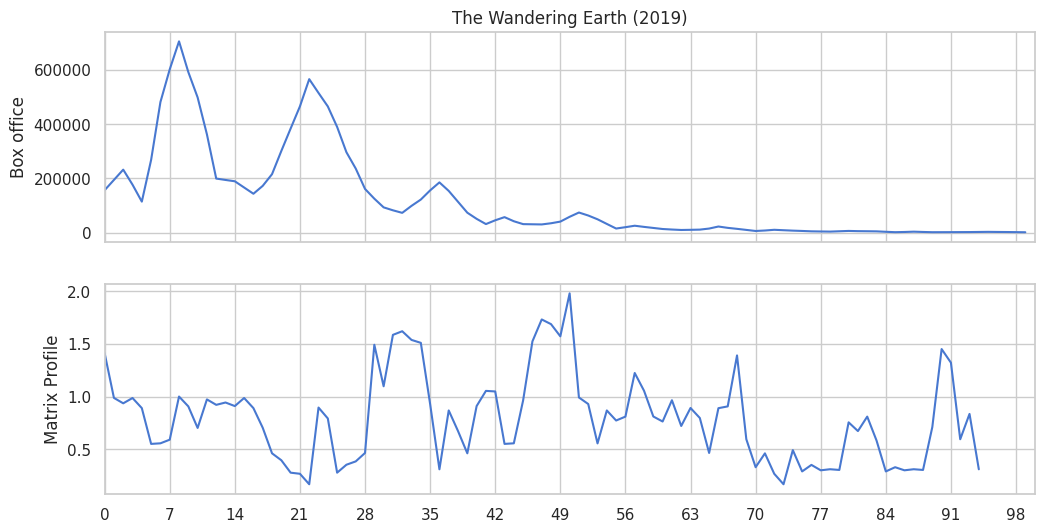

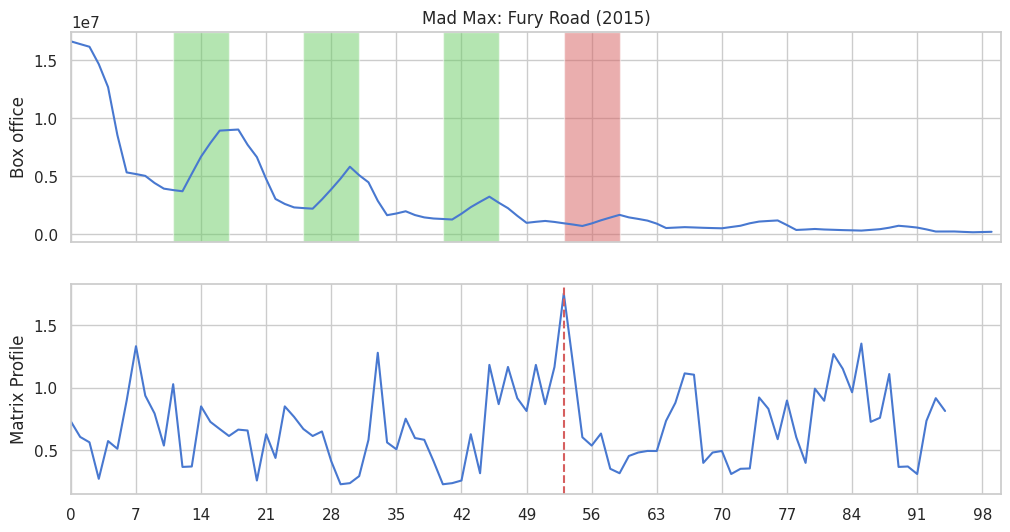

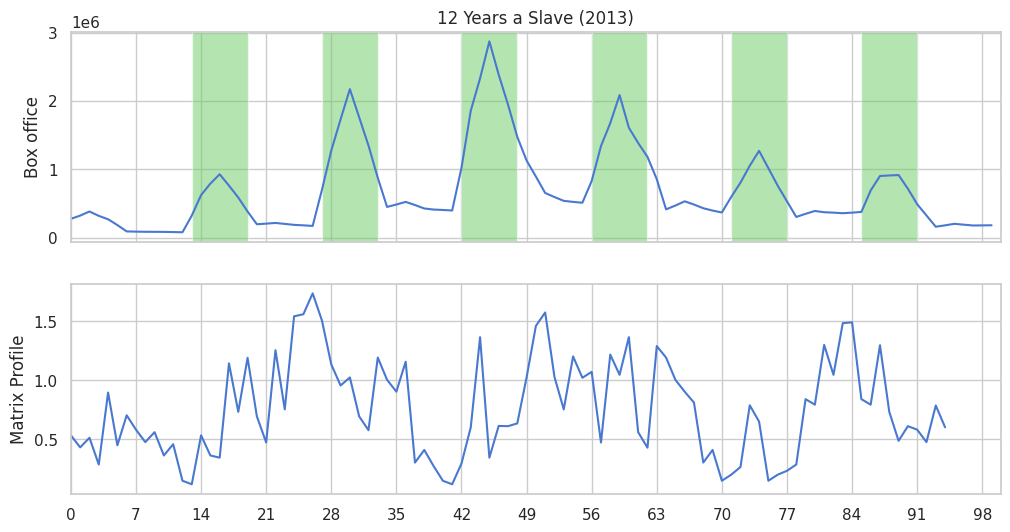

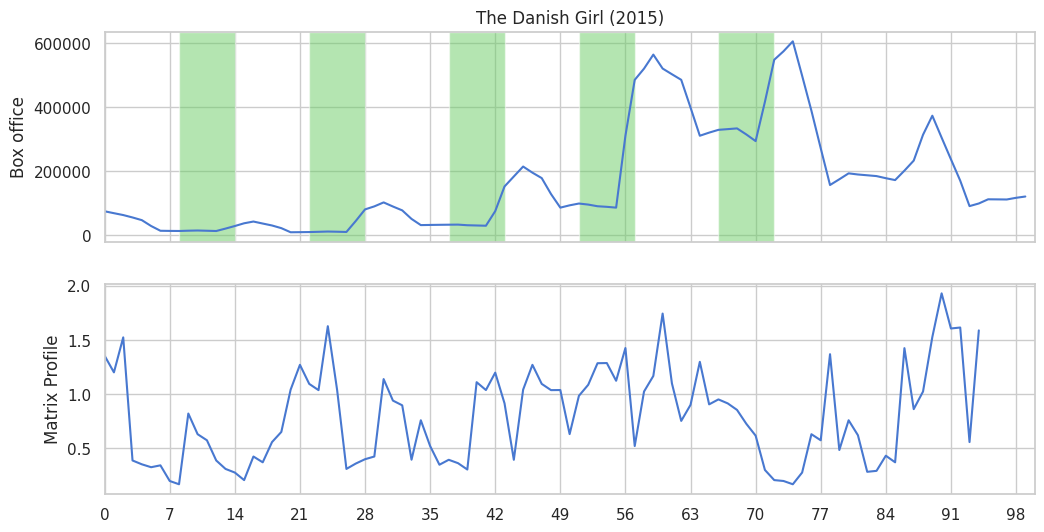

In [18]:
for movie_id in shape_medoids:
    axs = plot_ts_and_matrix_profile(movie_id)
    plot_motifs(movie_id, axs)
    plot_discords(movie_id, axs)
    plt.show()

### Structural features-based clustering medoids

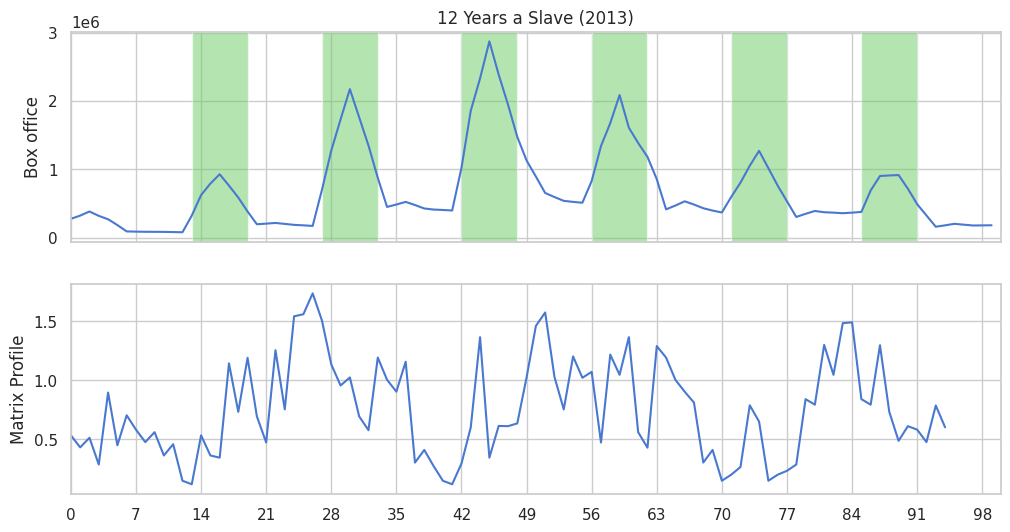

/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/stumpy/motifs.py:380: UserWarning: No motifs were found. You may consider increasing the `cutoff` (e.g., cutoff=0.35884723446639477) and/or increasing the `max_distance `(e.g., max_distance=np.inf).
  warnings.warn(msg)


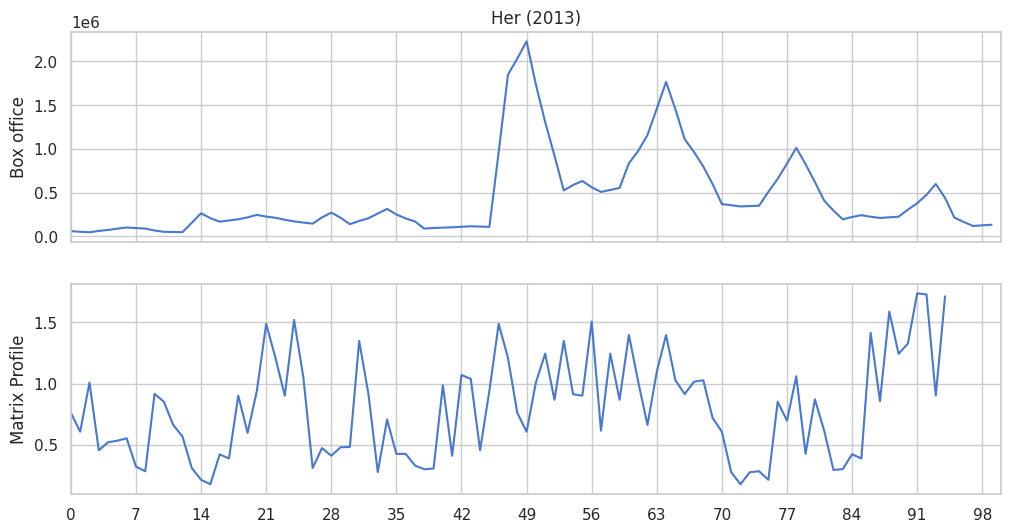

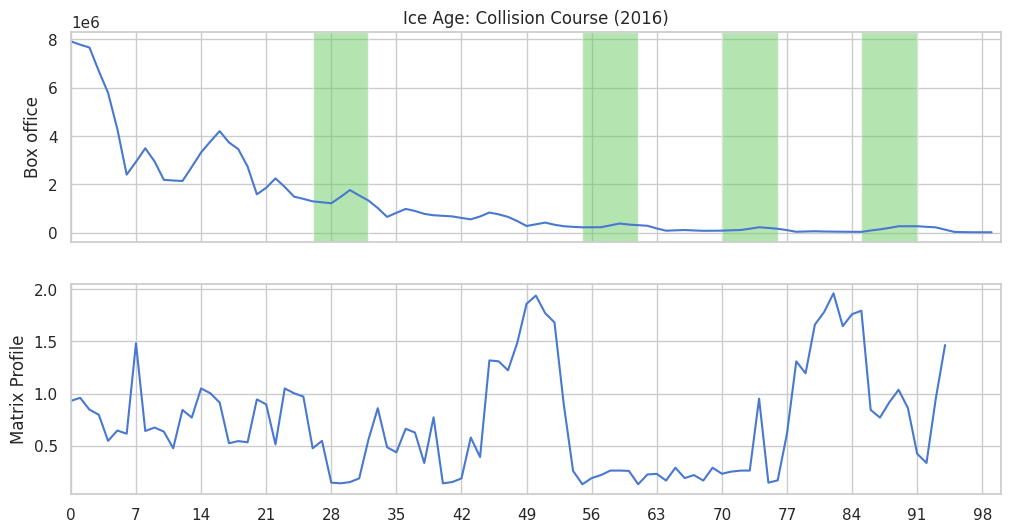

/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/stumpy/motifs.py:380: UserWarning: No motifs were found. You may consider increasing the `cutoff` (e.g., cutoff=0.6206456343229793) and/or increasing the `max_distance `(e.g., max_distance=np.inf).
  warnings.warn(msg)


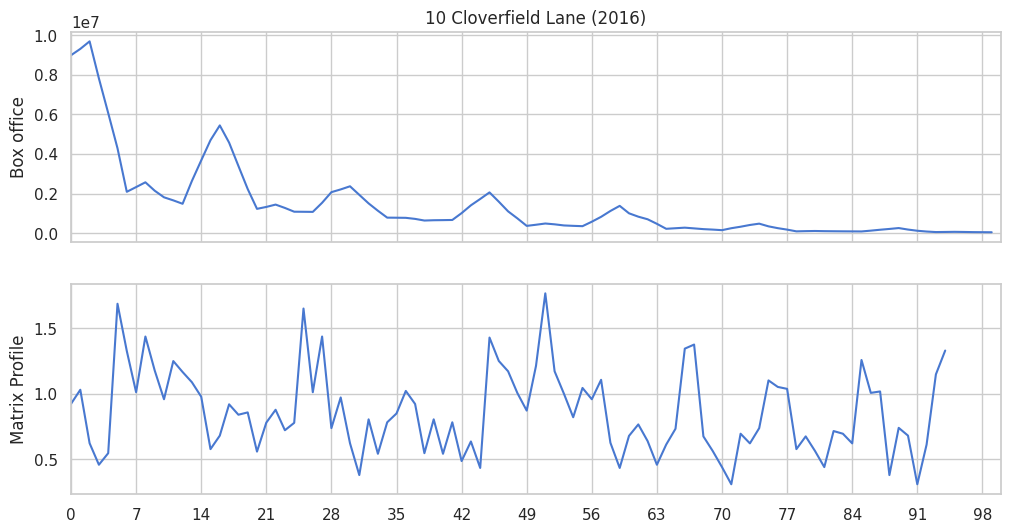

In [19]:
for movie_id in structure_medoids:
    axs = plot_ts_and_matrix_profile(movie_id)
    plot_motifs(movie_id, axs)
    plot_discords(movie_id, axs)
    plt.show()

## Search for discords in the entire dataset

In [20]:
%%time
ts_with_discords = []

for ts in mp.index:
    matrix_profile = mp.loc[ts].values
    ts_discords = get_discords(matrix_profile)
    if ts_discords:
        ts_with_discords.append((ts, ts_discords))



CPU times: user 126 ms, sys: 5 ms, total: 131 ms
Wall time: 127 ms


In [21]:
print(len(ts_with_discords))
train.loc[[idx for idx, _ in ts_with_discords]].iloc[:,:13].sort_values('numVotes', ascending=False).head()

89


,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,awards,nominations,rating,genre,rating_category,totalGrossIncome,awardsRatio
id,,,,,,,,,,,,,
tt0993846,The Wolf of Wall Street,2013,180,1711865,['US'],True,38.0,180.0,8.2,"['Biography', 'Comedy', 'Crime']",High,2.150253e+08,0.174312
tt1392190,Mad Max: Fury Road,2015,120,1177539,"['AU', 'US']",True,245.0,234.0,8.1,"['Action', 'Adventure', 'Sci-Fi']",High,2.897738e+08,0.511482
tt2488496,Star Wars: Episode VII - The Force Awakens,2015,138,1007831,"['US', 'GB']",True,64.0,140.0,7.8,"['Action', 'Adventure', 'Sci-Fi']",High,1.763034e+09,0.313725
tt2395427,Avengers: Age of Ultron,2015,141,971638,['US'],True,8.0,52.0,7.3,"['Action', 'Adventure', 'Sci-Fi']",High,8.590129e+08,0.133333
tt1825683,Black Panther,2018,134,885839,['US'],NaN,NaN,NaN,7.3,"['Action', 'Adventure', 'Sci-Fi']",High,1.290769e+09,0.000000


## Conserved patterns

In [22]:
mad_max = train_X.loc[shape_medoids[1], 'value']
twelve_years = train_X.loc[shape_medoids[2], 'value']

mad_max_mp = stumpy.stump(mad_max,
                          m,
                          twelve_years,
                          ignore_trivial=False)

In [23]:
def find_conserved_patterns(ts1, ts2):
    mp = stumpy.stump(ts1, m, ts2, ignore_trivial=False)
    ts1_idx = mp.P_.argmin()
    ts2_idx = mp.I_[ts1_idx]
    dist = mp.P_[ts1_idx]
    return ts1_idx, ts2_idx, dist

In this case the best matching pattern is symmetric

In [24]:
print(find_conserved_patterns(mad_max, twelve_years))
print(find_conserved_patterns(twelve_years, mad_max))

(np.int64(40), np.int64(25), np.float64(0.058673588708726424))
(np.int64(25), np.int64(40), np.float64(0.058673588708737776))


In [25]:
mad_max_motif_index, twelve_years_motif_index, _ = find_conserved_patterns(mad_max, twelve_years)

print(f"The motif is located at index {mad_max_motif_index} of 'Mad Max: Fury Road'")
print(f"The motif is located at index {twelve_years_motif_index} of 'Twelve Years a Slave")

The motif is located at index 40 of 'Mad Max: Fury Road'
The motif is located at index 25 of 'Twelve Years a Slave


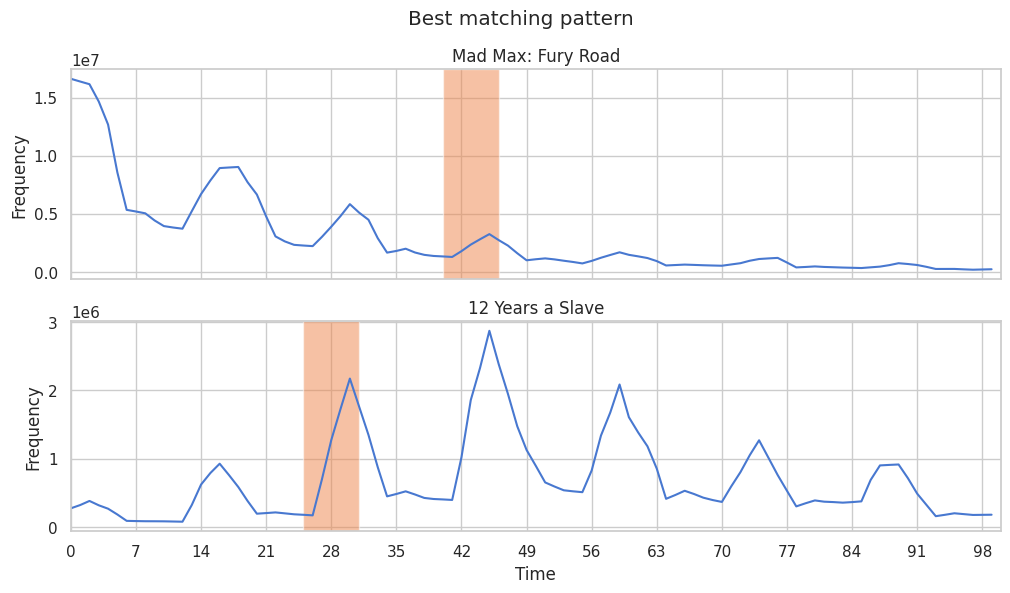

In [29]:
fig, axs = plt.subplots(2, sharex=True)
plt.suptitle('Best matching pattern')

axs[0].set_title('Mad Max: Fury Road')
axs[1].set_title('12 Years a Slave')

axs[1].set_xlabel('Time')
axs[0].set_ylabel('Frequency')
axs[1].set_ylabel('Frequency')

axs[0].plot(mad_max)
axs[1].plot(twelve_years)
plt.xticks(np.arange(0, 100, 7))
plt.xlim((0, 100))



lower, upper = axs[0].get_ylim()
height = upper - lower
rect = Rectangle((mad_max_motif_index, lower), m, height, facecolor='C1', alpha=.5)
axs[0].add_patch(rect)


lower, upper = axs[1].get_ylim()
height = upper - lower
rect = Rectangle((twelve_years_motif_index, lower), m, height, facecolor='C1', alpha=.5)
axs[1].add_patch(rect)

plt.show()

Interestingly, this conserved pattern is also a motif in *Mad Max: Fury Road*.
This may suggest that the seasonal peaks in movies from the two clusters are not so different afer all, and may reflect a general pattern of movie-goers behaviour.

In [27]:
mad_max_z_norm_motif = core.z_norm(mad_max.loc[mad_max_motif_index:mad_max_motif_index+m].values)
twelve_years_z_norm_motif = core.z_norm(twelve_years.loc[twelve_years_motif_index:twelve_years_motif_index+m].values)

Text(0, 0.5, 'Normalized Box Office')

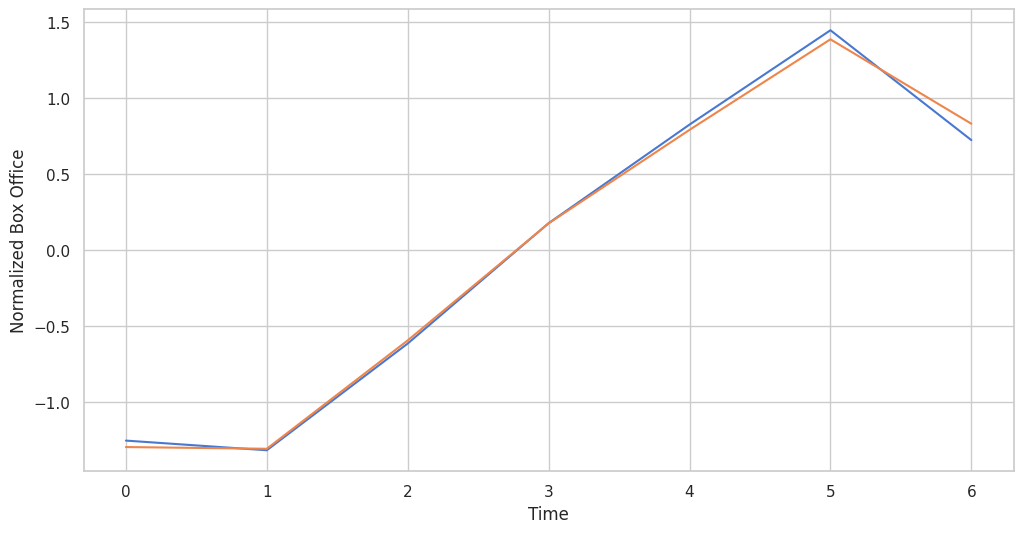

In [28]:
plt.plot(mad_max_z_norm_motif, label='Mad Max: Fury Road')
plt.plot(twelve_years_z_norm_motif, label='Twelve Years a Slave')

plt.xlabel('Time')
plt.ylabel('Normalized Box Office')